In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import os 
from synth_pat.paths import Paths

In [3]:
demo = pd.read_csv(f'{Paths.DATA}/full_demographics.csv', index_col = 'SubjectID')

In [4]:
list1 = ['sub-2015060902', 'sub-2015121001', 'sub-2019012101', 'sub-2019052301', 'sub-2015060401', 'sub-2015061901', 'sub-2015111402', 'sub-2019012402', 'sub-2019052302']
list2 = ['sub-2015052501', 'sub-2015120501', 'sub-2015120401']
list3 = [pid for pid in os.listdir(f'{Paths.RESULTS}') if pid not in list1+list2]
list4 = ['sub-2015060902', 'sub-2015121001', 'sub-2015060401', 'sub-2015061901', 'sub-2015111402', 'sub-2015052501', 'sub-2015120501', 'sub-2015120401']
list5 = [pid for pid in list1+list2 if pid not in list4]

type_of_sweep = 'bold_sweep'
type_of_ext = 'traditional'

emp_data_feat = pd.read_csv(f'{Paths.DATA}/ALL_{type_of_ext}_full_extracted_features.csv', index_col = 'pid')
emp_data_feat['diagnosis'] = demo['diagnosis']

In [56]:
mean_params = []
for pid in list3:
    pid_idx = int(pid.split('-')[1])
    file = f'{Paths.RESULTS}/{pid}/{type_of_sweep}_{type_of_ext}_estimated_mean_params.npz'
    mean_file = np.load(file)
    mean_ws = float(mean_file['ws'])
    mean_ctx = float(mean_file['njdopa_ctx'])
    mean_str = float(mean_file['njdopa_str'])
    mean_params.append([mean_ws, mean_ctx, mean_str, *emp_data_feat.loc[pid_idx].values])


In [57]:
res_df = pd.DataFrame(data=mean_params, columns=['est_ws', 'est_njdopa_ctx', 'est_njdopa_str', *emp_data_feat.columns])
res_df.drop(columns=['Unnamed: 0'], inplace=True)

In [58]:
print(res_df['est_ws'].dtype)
print(type(res_df['est_ws'].iloc[0]))

float64
<class 'numpy.float64'>


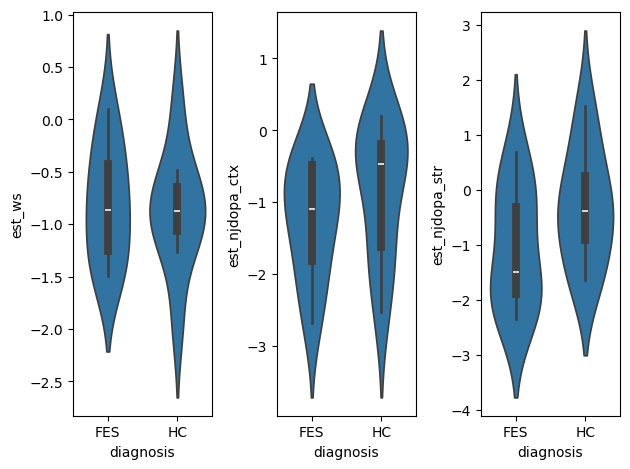

In [59]:
fig, axes = plt.subplots(1, 3)
params = ['est_ws', 'est_njdopa_ctx', 'est_njdopa_str']
for i, p in enumerate(params):
    sns.violinplot(
        data=res_df,
        x='diagnosis',
        y=p,
        ax=axes[i]
    )

plt.tight_layout()

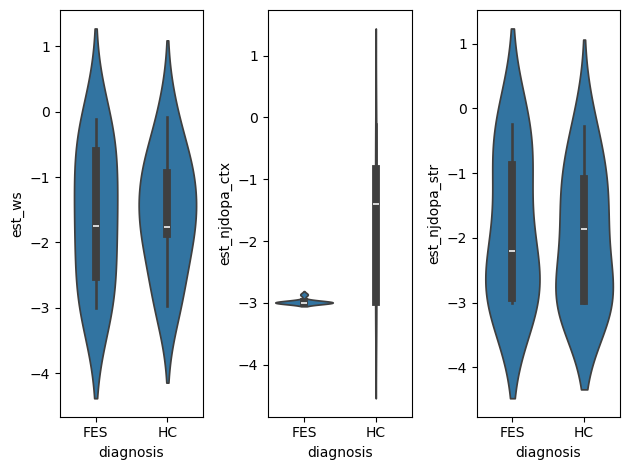

In [49]:
mean_params = []
for pid in list3:
    pid_idx = int(pid.split('-')[1])
    file = f'{Paths.RESULTS}/{pid}/{type_of_sweep}_{type_of_ext}_estimated_mode_params.npz'
    mean_file = np.load(file)
    mean_ws = float(mean_file['ws'])
    mean_ctx = float(mean_file['njdopa_ctx'])
    mean_str = float(mean_file['njdopa_str'])
    mean_params.append([mean_ws, mean_ctx, mean_str, *emp_data_feat.loc[pid_idx].values])

res_df = pd.DataFrame(data=mean_params, columns=['est_ws', 'est_njdopa_ctx', 'est_njdopa_str', *emp_data_feat.columns])
res_df.drop(columns=['Unnamed: 0'], inplace=True)

fig, axes = plt.subplots(1, 3)
params = ['est_ws', 'est_njdopa_ctx', 'est_njdopa_str']
for i, p in enumerate(params):
    sns.violinplot(
        data=res_df,
        x='diagnosis',
        y=p,
        ax=axes[i]
    )

plt.tight_layout()


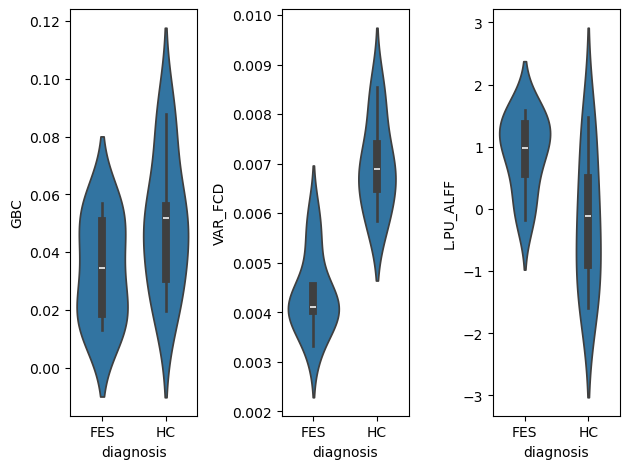

In [54]:
fig, axes = plt.subplots(1, 3)
params = ['GBC', 'VAR_FCD', 'L.PU_ALFF']
for i, p in enumerate(params):
    sns.violinplot(
        data=res_df,
        x='diagnosis',
        y=p,
        ax=axes[i]
    )

plt.tight_layout()


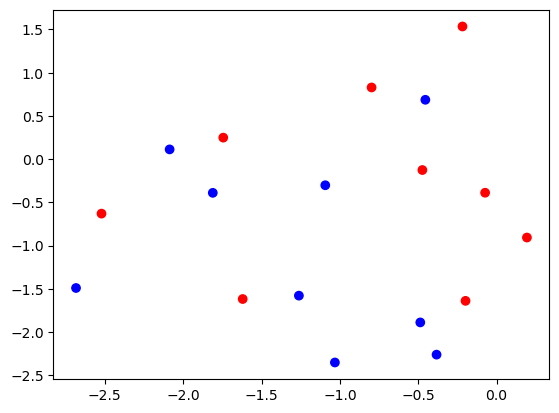

In [66]:
c = ['b' if res_df.loc[i, 'diagnosis'] == 'FES' else 'r'
     for i in res_df.index]
plt.scatter(res_df['est_njdopa_ctx'], res_df['est_njdopa_str'], c=c)

In [78]:
from scipy import stats
from sklearn.preprocessing import StandardScaler
## Using the internal function from SciPy Package  
sc = StandardScaler()
x = res_df[res_df['diagnosis']=='HC']['est_njdopa_str'].values.reshape(-1, 1)
y = res_df[res_df['diagnosis']=='FES']['est_njdopa_str'].values.reshape(-1, 1)
t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)  
print("t-statistic = " + str(t_stat))  
print("p-value = " + str(p_val))


t-statistic = [1.47590847]
p-value = [0.15940503]


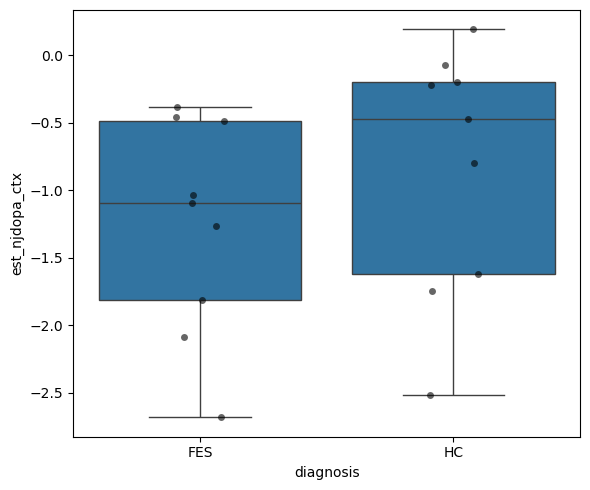

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.boxplot(data=res_df, x='diagnosis', y='est_njdopa_ctx')
sns.stripplot(data=res_df, x='diagnosis', y='est_njdopa_ctx',
              color='black', alpha=0.6)
plt.tight_layout()
plt.show()

In [85]:
from scipy import stats

x = res_df[res_df['diagnosis']=='HC']['est_njdopa_ctx'].values
y = res_df[res_df['diagnosis']=='FES']['est_njdopa_ctx'].values

t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)

print("Welch t-test")
print("t =", t_stat)
print("p =", p_val)

Welch t-test
t = 1.047257461665443
p = 0.3108663851291279


In [86]:
u_stat, p_val_u = stats.mannwhitneyu(x, y, alternative='two-sided')

print("Mann-Whitney U test")
print("U =", u_stat)
print("p =", p_val_u)

Mann-Whitney U test
U = 56.0
p = 0.18532630419857943


In [3]:
import numpy as np

mean_diff = np.mean(x) - np.mean(y)
pooled_sd = np.sqrt((np.var(x, ddof=1) + np.var(y, ddof=1)) / 2)
cohens_d = mean_diff / pooled_sd

print("Cohen's d =", cohens_d)

NameError: name 'x' is not defined

In [24]:
hc_distr = []
pat_distr = []
base_distr = []
follow_distr = []

for pid in list3:
    file = f'{Paths.RESULTS}/{pid}/bold_sweep_aCompCor50_posterior_distr.npz'
    pid_idx = int(pid.split('-')[1])
    if demo.loc[pid_idx, 'diagnosis'] == 'HC': hc_distr.append(np.load(file)['est_params'])
    elif demo.loc[pid_idx, 'diagnosis'] == 'FES': pat_distr.append(np.load(file)['est_params'])

#for pid in list4:
    #file = f'{Paths.RESULTS}/{pid}/bold_sweep_aCompCor50_posterior_distr.npy'
    #pid_idx = int(pid.split('-')[1])
    #if demo.loc[pid_idx, 'diagnosis'] == 'HC': hc_distr.append(np.load(file))
    #if demo.loc[pid_idx, 'wave'] == 'Baseline' and demo.loc[pid_idx, 'diagnosis'] != 'HC': hc_distr.append(np.load(file))
    #elif demo.loc[pid_idx, 'wave'] == 'Followup' and demo.loc[pid_idx, 'diagnosis'] != 'HC': pat_distr.append(np.load(file))


#for pid in list4:
#    file = f'{Paths.RESULTS}/{pid}/bigger_we_bold_sweep_daniela_posterior_distr.npz'
#    pid_idx = int(pid.split('-')[1])
    #if demo.loc[pid_idx, 'diagnosis'] == 'HC': hc_distr.append(np.load(file))
#    if demo.loc[pid_idx, 'wave'] == 'Baseline' and demo.loc[pid_idx, 'diagnosis'] != 'HC': hc_distr.append(np.load(file)['est_params'])
    #if demo.loc[pid_idx, 'wave'] == 'Baseline' and demo.loc[pid_idx, 'diagnosis'] == 'HC': hc_distr.append(np.load(file))
#    elif demo.loc[pid_idx, 'wave'] == 'Followup' and demo.loc[pid_idx, 'diagnosis'] != 'HC': pat_distr.append(np.load(file)['est_params'])


#for pid in list5:
    #file = f'{Paths.RESULTS}/{pid}/bold_sweep_daniela_posterior_distr.npy'
    #pid_idx = int(pid.split('-')[1])
    #if demo.loc[pid_idx, 'diagnosis'] == 'HC': hc_distr.append(np.load(file))
#    if demo.loc[pid_idx, 'wave'] == 'Baseline' and demo.loc[pid_idx, 'diagnosis'] == 'HC': hc_distr.append(np.load(file))
    #if demo.loc[pid_idx, 'wave'] == 'Baseline' and demo.loc[pid_idx, 'diagnosis'] == 'HC': hc_distr.append(np.load(file))
#    elif demo.loc[pid_idx, 'wave'] == 'Followup' and demo.loc[pid_idx, 'diagnosis'] == 'HC': pat_distr.append(np.load(file))

hc_distr = np.array(hc_distr)
pat_distr = np.array(pat_distr)

print(hc_distr.shape)

(9, 1000, 3)


(9, 1000)
{'mean_diff': -0.20188116, 'credible_interval': array([-0.55307711,  0.05975767]), 'prob_FES_gt_HC': 0.0692, 'diff_samples': array([ 0.05445522, -0.02237612, -0.28107864, ..., -0.30248272,
        0.04751372, -0.34299746], dtype=float32)}
(9, 1000)
{'mean_diff': -0.3372899, 'credible_interval': array([-6.72182290e-01,  1.79131329e-04]), 'prob_FES_gt_HC': 0.0252, 'diff_samples': array([-0.6440981 , -0.07761353, -0.523336  , ..., -0.12739745,
       -0.57219416, -0.29782552], dtype=float32)}
(9, 1000)
{'mean_diff': 0.12297875, 'credible_interval': array([-0.11037259,  0.3464478 ]), 'prob_FES_gt_HC': 0.8573, 'diff_samples': array([0.16743803, 0.24928415, 0.24058497, ..., 0.15625083, 0.35378408,
       0.03837276], dtype=float32)}


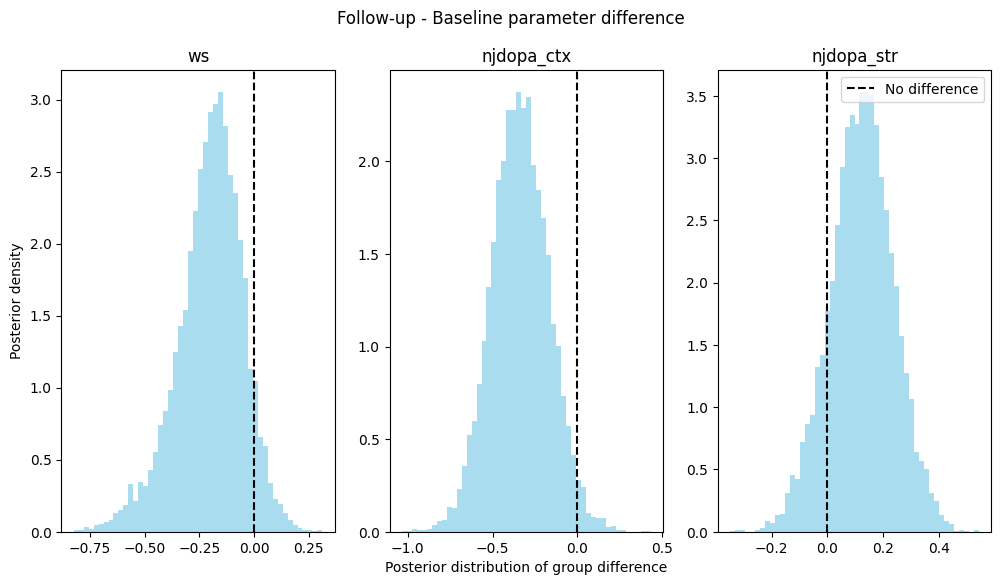

In [25]:
selected_params = np.load(file)['param_names']

n_HC, n_samples_HC = hc_distr[:,:,0].shape
n_FES, n_samples_FES = pat_distr[:,:,0].shape

fig, axes = plt.subplots(1,3, figsize=(12,6))
for i, param in enumerate(selected_params):
    diff_samples = []

    hc_distr_i = np.array(hc_distr)[:,:,i]
    pat_distr_i = np.array(pat_distr)[:,:,i]
    print(pat_distr_i.shape)

    for _ in range(10000):
        # Randomly pick one posterior sample per subject
        hc_mean = np.mean([np.random.choice(hc_distr_i[i]) for i in range(n_HC)])
        fes_mean = np.mean([np.random.choice(pat_distr_i[i]) for i in range(n_FES)])
        diff_samples.append(fes_mean - hc_mean)

    diff_samples = np.array(diff_samples)

    mean_diff = diff_samples.mean()
    credible_interval = np.percentile(diff_samples, [2.5, 97.5])
    prob_FES_gt_HC = np.mean(diff_samples > 0)

    results = {
        "mean_diff": mean_diff,
        "credible_interval": credible_interval,
        "prob_FES_gt_HC": prob_FES_gt_HC,
        "diff_samples": diff_samples
    }

    print(results)

    axes[i].hist(diff_samples, bins=50, density=True, alpha=0.7, color='skyblue')
    axes[i].axvline(0, color='black', linestyle='--', label='No difference')
    axes[i].set_title(param)

axes[0].set_ylabel('Posterior density') 
axes[1].set_xlabel('Posterior distribution of group difference')
plt.suptitle('Follow-up - Baseline parameter difference')
plt.legend()
plt.show()


In [27]:
hc_means = np.array([np.mean(d, axis=0) for d in hc_distr])
pat_means = np.array([np.mean(d, axis=0) for d in pat_distr])

hc_medians = np.array([np.median(d, axis=0) for d in hc_distr])
pat_medians = np.array([np.median(d, axis=0) for d in pat_distr])

from scipy.stats import mannwhitneyu

for i in range(hc_medians.shape[1]):
    stat, p = mannwhitneyu(hc_medians[:, i], pat_medians[:, i], alternative='two-sided')
    print(f"Param {i}: p = {p:.5f}")

from scipy.stats import ttest_ind

for i in range(hc_medians.shape[1]):
    stat, p = ttest_ind(hc_medians[:, i], pat_medians[:, i])
    print(f"Param {i}: p = {p:.5f}")

Param 0: p = 0.85982
Param 1: p = 0.92964
Param 2: p = 0.92964
Param 0: p = 0.66592
Param 1: p = 0.62098
Param 2: p = 0.72956


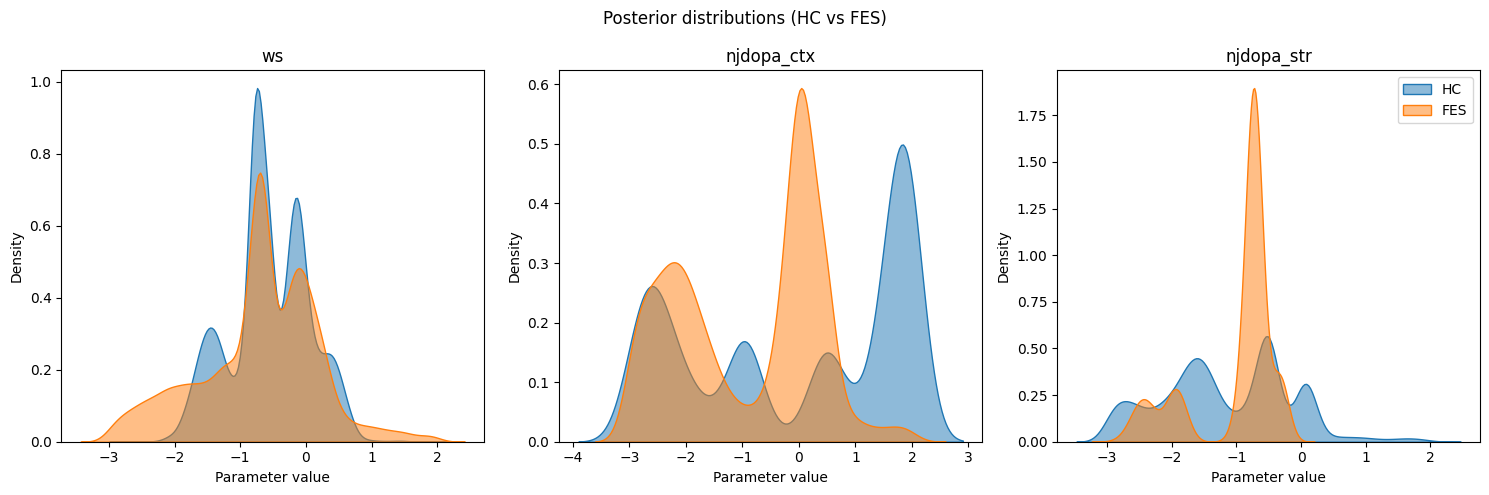

In [15]:
import seaborn as sns

fig, axes = plt.subplots(1, len(selected_params), figsize=(15, 5))

for i, param in enumerate(selected_params):
    hc_distr_i = np.array(hc_distr)[:, :, i].flatten()
    pat_distr_i = np.array(pat_distr)[:, :, i].flatten()

    sns.kdeplot(hc_distr_i, ax=axes[i], label='HC', fill=True, alpha=0.5)
    sns.kdeplot(pat_distr_i, ax=axes[i], label='FES', fill=True, alpha=0.5)

    axes[i].set_title(param)
    axes[i].set_xlabel("Parameter value")

axes[0].set_ylabel("Density")
axes[-1].legend()
plt.suptitle("Posterior distributions (HC vs FES)")
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

rows = []

for i, param in enumerate(selected_params):
    hc_distr_i = np.array(hc_distr)[:, :, i]
    pat_distr_i = np.array(pat_distr)[:, :, i]

    # HC
    for subj in range(n_HC):
        for val in hc_distr_i[subj]:
            rows.append([param, 'HC', f'HC_{subj}', val])

    # FES
    for subj in range(n_FES):
        for val in pat_distr_i[subj]:
            rows.append([param, 'FES', f'FES_{subj}', val])

df = pd.DataFrame(rows, columns=['param', 'group', 'subject', 'value'])

/tmp/ipykernel_3552490/132313177.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_3552490/132313177.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_3552490/132313177.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_3552490/132313177.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_3552490/132313177.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_3552490/132313177.py:21: UserWarning: Fix

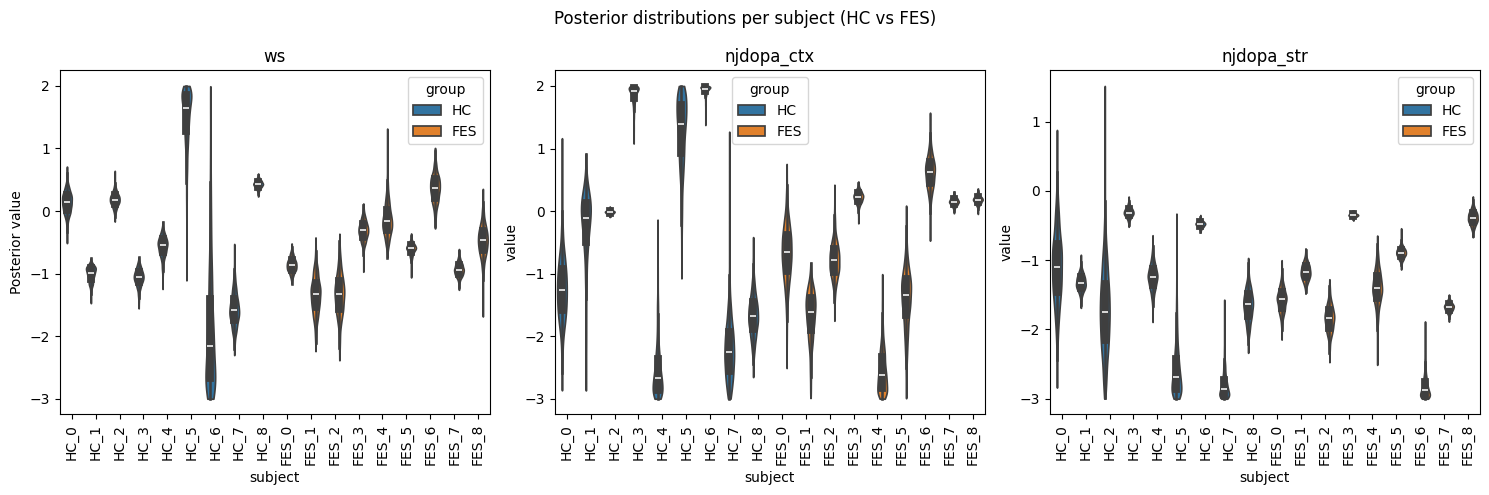

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(selected_params), figsize=(15, 5), sharey=False)

for i, param in enumerate(selected_params):
    sub_df = df[df['param'] == param]

    sns.violinplot(
        data=sub_df,
        x='subject',
        y='value',
        hue='group',
        dodge=True,
        cut=0,
        scale='width',
        ax=axes[i]
    )

    axes[i].set_title(param)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)

axes[0].set_ylabel("Posterior value")
plt.suptitle("Posterior distributions per subject (HC vs FES)")
plt.tight_layout()
plt.show()

In [21]:
hc_medians = []
pat_medians = []

for i, param in enumerate(selected_params):
    hc_distr_i = np.array(hc_distr)[:, :, i]
    pat_distr_i = np.array(pat_distr)[:, :, i]

    hc_medians.append(np.percentile(hc_distr_i, 50, axis=1))   # (n_HC,)
    pat_medians.append(np.percentile(pat_distr_i, 50, axis=1)) # (n_FES,)

In [24]:
import pandas as pd

rows = []

for i, param in enumerate(selected_params):
    for val in hc_medians[i]:
        rows.append([param, 'HC', val])
    for val in pat_medians[i]:
        rows.append([param, 'FES', val])

df = pd.DataFrame(rows, columns=['param', 'group', 'value'])

/tmp/ipykernel_4028697/3030052226.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


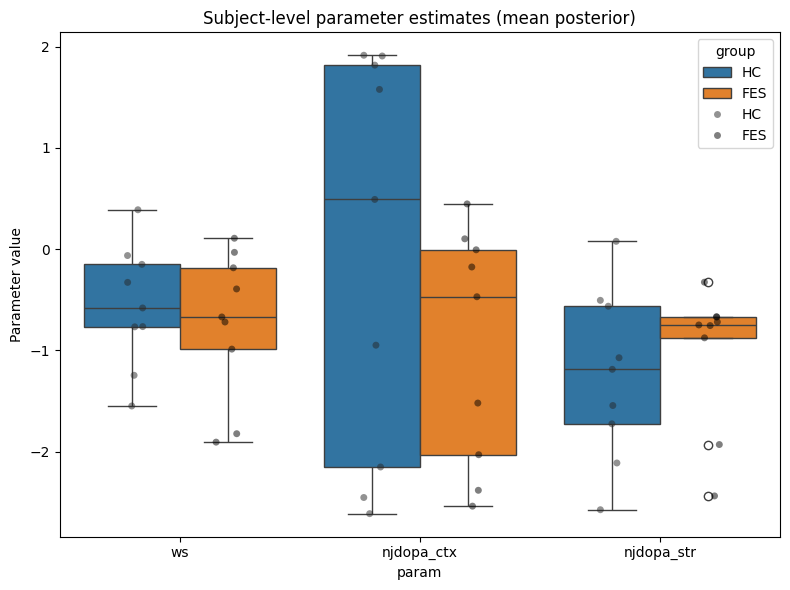

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='param',
    y='value',
    hue='group',
)

# Add individual points (VERY important)
sns.stripplot(
    data=df,
    x='param',
    y='value',
    hue='group',
    dodge=True,
    color='black',
    alpha=0.5
)

plt.title("Subject-level parameter estimates (mean posterior)")
plt.ylabel("Parameter value")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3231058/28815891.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = cm.get_cmap("viridis")


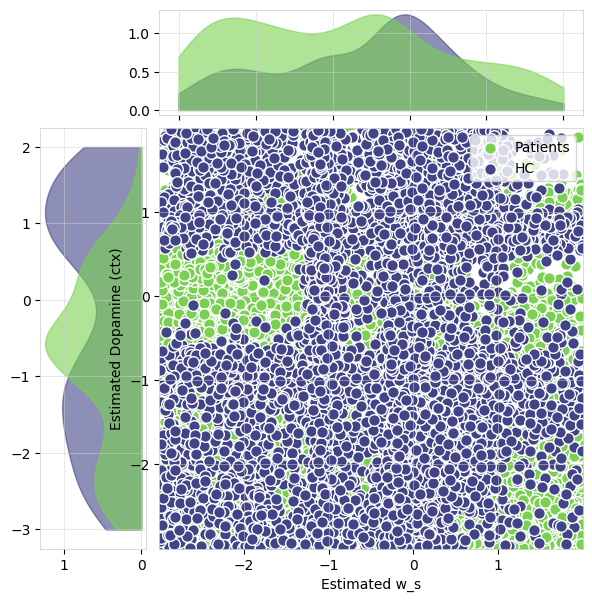

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.cm as cm

# ----------------
# Data
# ----------------
traditional_no_nan = posterior_df.dropna()
x = traditional_no_nan["ws_est"]
y = traditional_no_nan["njdopa_ctx_est"]

hc_mask = posterior_df["diagnosis"] == "HC"

x_hc = x[hc_mask]
y_hc = y[hc_mask]

x_pat = x[~hc_mask]
y_pat = y[~hc_mask]

# ----------------
# Viridis colors
# ----------------
viridis = cm.get_cmap("viridis")
hc_color = viridis(0.2)       # purple-blue
patient_color = viridis(0.8)  # yellow-green

# ----------------
# Figure layout
# ----------------
fig = plt.figure(figsize=(7,7))

gs = fig.add_gridspec(
    2,2,
    width_ratios=(1,4),
    height_ratios=(1,4),
    wspace=0.05,
    hspace=0.05
)

ax_histx = fig.add_subplot(gs[0,1])
ax_histy = fig.add_subplot(gs[1,0])
ax_scatter = fig.add_subplot(gs[1,1])

# ----------------
# Scatter
# ----------------
ax_scatter.scatter(
    x_pat, y_pat,
    color=patient_color,
    s=70,
    edgecolors="white",
    label="Patients"
)

ax_scatter.scatter(
    x_hc, y_hc,
    color=hc_color,
    s=70,
    edgecolors="white",
    label="HC"
)

# ----------------
# Axis limits
# ----------------
xlim = (x.min(), x.max())
ylim = (y.min(), y.max())

ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)

# ----------------
# KDE function
# ----------------
def normalized_kde(ax, data_list, colors, axis="x", range_=None, scale=0.25, bw=0.3):

    for data, color in zip(data_list, colors):

        kde = gaussian_kde(data, bw_method=bw)

        vals = np.linspace(range_[0], range_[1], 200)
        dens = kde(vals)

        dens = dens / dens.max() * (range_[1]-range_[0]) * scale

        if axis == "x":
            ax.fill_between(vals, 0, dens, color=color, alpha=0.6)
        else:
            ax.fill_betweenx(vals, 0, dens, color=color, alpha=0.6)

# ----------------
# KDE marginals
# ----------------
normalized_kde(
    ax_histx,
    [x_hc, x_pat],
    [hc_color, patient_color],
    axis="x",
    range_=xlim
)

ax_histx.tick_params(labelbottom=False)

normalized_kde(
    ax_histy,
    [y_hc, y_pat],
    [hc_color, patient_color],
    axis="y",
    range_=ylim
)

ax_histy.invert_xaxis()

# ----------------
# Labels
# ----------------
ax_scatter.set_xlabel("Estimated w_s")
ax_scatter.set_ylabel("Estimated Dopamine (ctx)")

# ----------------
# Style
# ----------------
for ax in [ax_scatter, ax_histx, ax_histy]:
    ax.grid(True, color="lightgray", linewidth=0.5, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_color("lightgray")
        spine.set_linewidth(0.6)

ax_scatter.legend()

plt.show()

/tmp/ipykernel_3231058/2155944900.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = cm.get_cmap('viridis')


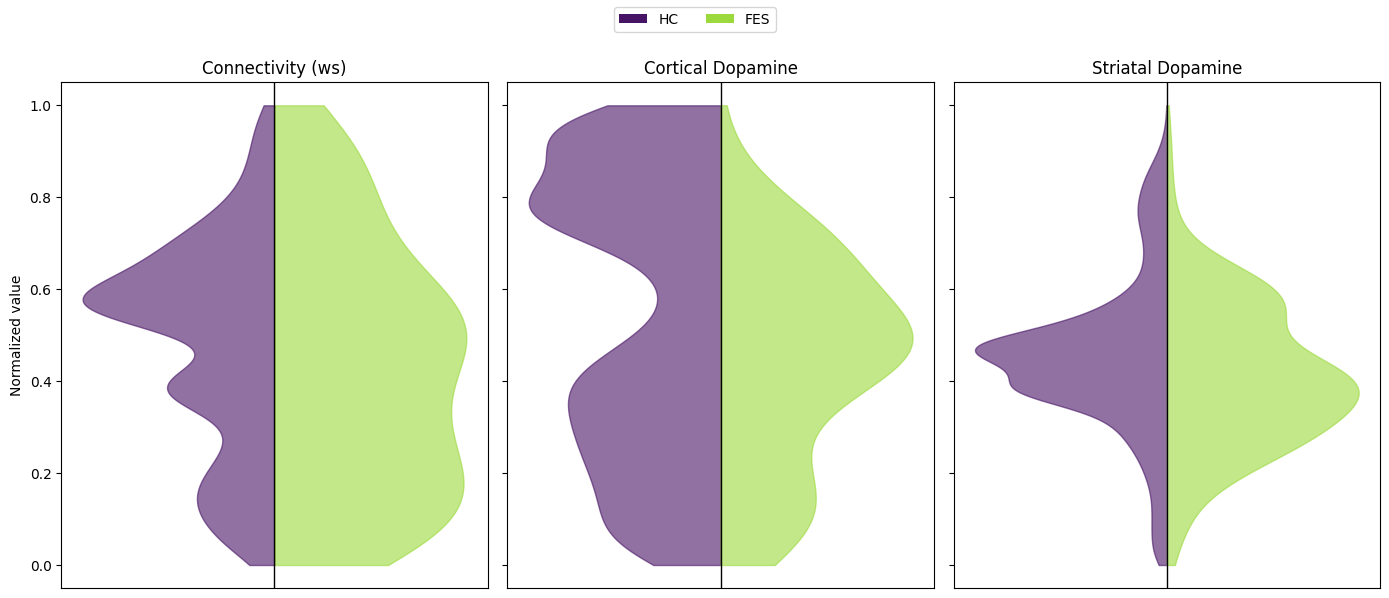

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MinMaxScaler
from matplotlib.patches import Patch
import matplotlib.cm as cm

# Colormap
viridis = cm.get_cmap('viridis')
hc_color = viridis(0.05)      # purple-blue
patient_color = viridis(0.85) # yellow-green

# Columns and nicer labels
features = {
    'ws_est': 'Connectivity (ws)',
    'njdopa_ctx_est': 'Cortical Dopamine',
    'njdopa_str_est': 'Striatal Dopamine'
}

fig, axes = plt.subplots(1, len(features), figsize=(14,6), sharey=True)

for ax, (feat, label) in zip(axes, features.items()):

    # --- collect data ---
    hc = posterior_df.loc[posterior_df['diagnosis']=='HC', feat].dropna()
    patients = posterior_df.loc[posterior_df['diagnosis']!='HC', feat].dropna()
    
    # --- normalize between 0 and 1 ---
    scaler = MinMaxScaler()
    combined = np.concatenate([hc, patients]).reshape(-1,1)
    scaler.fit(combined)

    hc = scaler.transform(hc.values.reshape(-1,1)).flatten()
    patients = scaler.transform(patients.values.reshape(-1,1)).flatten()

    # grid for KDE
    y = np.linspace(0,1,300)

    kde_hc = gaussian_kde(hc, bw_method=0.2)(y)
    kde_pat = gaussian_kde(patients, bw_method=0.4)(y)

    # normalize KDEs
    kde_hc /= kde_hc.max()
    kde_pat /= kde_pat.max()

    # scale for plot width
    scale = 0.9
    kde_hc *= scale
    kde_pat *= scale

    # --- Left half HC ---
    ax.fill_betweenx(y, -kde_hc, 0, color=hc_color, alpha=0.6)
    # --- Right half Patients ---
    ax.fill_betweenx(y, 0, kde_pat, color=patient_color, alpha=0.6)

    ax.axvline(0, color='black', lw=1)
    ax.set_xlim(-1,1)
    ax.set_title(label)
    ax.set_xticks([])

axes[0].set_ylabel("Normalized value")

# --- legend ---
legend_elements = [
    Patch(facecolor=hc_color, label='HC'),
    Patch(facecolor=patient_color, label='FES')
]

fig.legend(handles=legend_elements, loc='upper center', ncol=2)

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

## Posterior Predictive Check

In [6]:
traditional = pd.read_csv(f'{Paths.DATA}/ALL_traditional_full_extracted_features.csv', index_col='pid')
traditional['diagnosis'] = demo['diagnosis']

In [8]:
dfs = []
for pid in traditional.index:
    pid_df = pd.read_csv(f'{Paths.RESULTS}/sub-{pid}/post_pred_check_mode_params_extracted_features.csv', index_col=0)
    dfs.append(pid_df)

df = pd.concat(dfs)
df.index = traditional.index

In [9]:
tokeep = [1272, 1280, 1273, 1860, 1858, 1269,
             1856, 1857, 1859, 1861, 1276,
             1271, 1278, 1279, 1198, 1864, 1863, 1862]
synth_res_df = df.loc[tokeep]

In [10]:
trad = traditional.loc[tokeep]

In [11]:
np.corrcoef(synth_res_df['L.PU_FC'], trad['L.PU_FC'])

array([[1.        , 0.22849288],
       [0.22849288, 1.        ]])

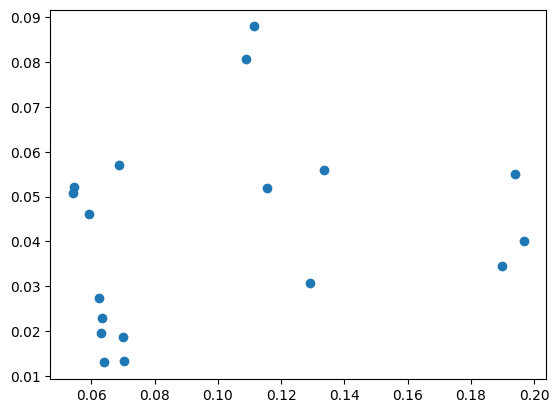

In [12]:
plt.scatter(synth_res_df['GBC'], trad['GBC'])

/tmp/ipykernel_3400297/1387500634.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = cm.get_cmap('viridis')


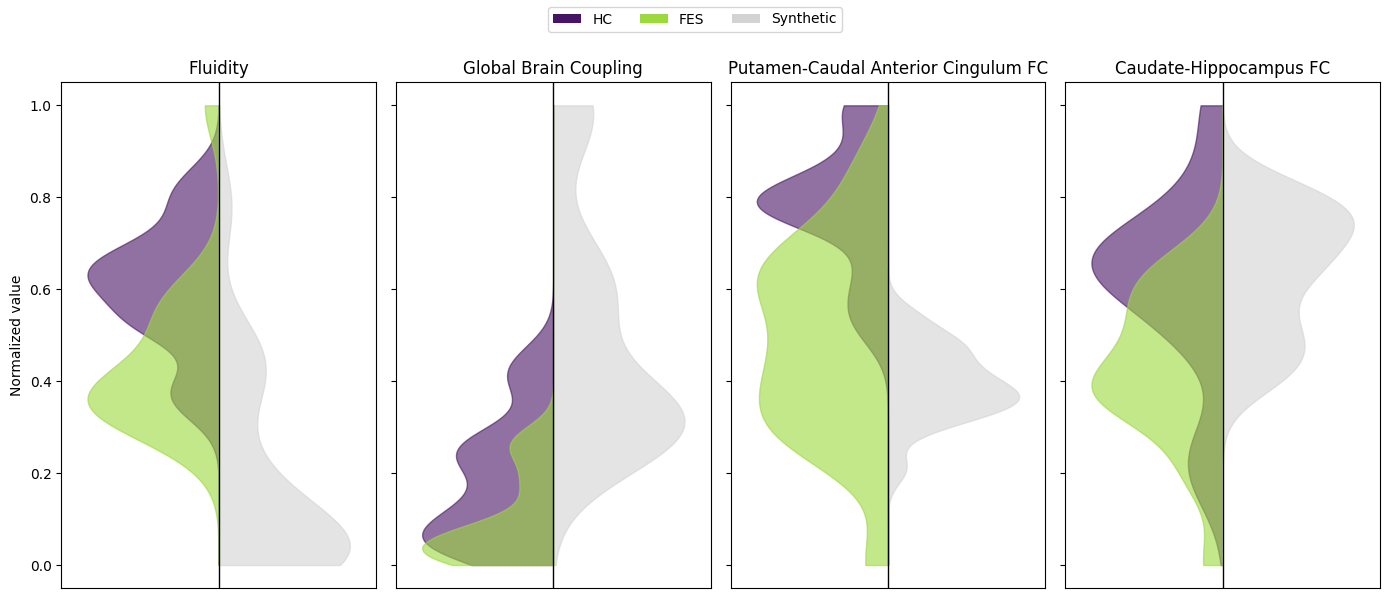

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MinMaxScaler
from matplotlib.patches import Patch

import matplotlib.cm as cm

viridis = cm.get_cmap('viridis')

hc_color = viridis(0.05)      # purple-blue
patient_color = viridis(0.85) # yellow-green

features = {
    'VAR_FCD': 'Fluidity',
    'GBC': 'Global Brain Coupling',
    'L.PU-L.CACG': 'Putamen-Caudal Anterior Cingulum FC',
    'L.CA-L.HI': 'Caudate-Hippocampus FC'
}

fig, axes = plt.subplots(1, len(features), figsize=(14,6), sharey=True)

for ax, (feat, label) in zip(axes, features.items()):

    # --- collect data ---
    hc = traditional.loc[traditional['diagnosis']=='HC', feat].dropna()
    patients = traditional.loc[traditional['diagnosis']!='HC', feat].dropna()
    synth = synth_res_df[feat].dropna()

    # --- normalize ---
    scaler = MinMaxScaler()
    combined = np.concatenate([hc, patients, synth]).reshape(-1,1)
    scaler.fit(combined)

    hc = scaler.transform(hc.values.reshape(-1,1)).flatten()
    patients = scaler.transform(patients.values.reshape(-1,1)).flatten()
    synth = scaler.transform(synth.values.reshape(-1,1)).flatten()

    # grid
    y = np.linspace(0,1,300)

    kde_hc = gaussian_kde(hc,bw_method=0.4)(y)
    kde_pat = gaussian_kde(patients, bw_method=0.4)(y)
    kde_syn = gaussian_kde(synth, bw_method=0.4)(y)

    kde_hc /= kde_hc.max()
    kde_pat /= kde_pat.max()
    kde_syn /= kde_syn.max()

    # left half overlays (traditional)
    ax.fill_betweenx(y, -kde_hc, 0, color=hc_color, alpha=0.6)
    ax.fill_betweenx(y, -kde_pat, 0, color=patient_color, alpha=0.6)

    # right half (synthetic)
    ax.fill_betweenx(y, 0, kde_syn, color='lightgray', alpha=0.6)

    ax.axvline(0, color='black', lw=1)

    ax.set_xlim(-1.2,1.2)
    ax.set_title(label)
    ax.set_xticks([])

axes[0].set_ylabel("Normalized value")

# legend
legend_elements = [
    Patch(facecolor=hc_color, label='HC'),
    Patch(facecolor=patient_color, label='FES'),
    Patch(facecolor='lightgray', label='Synthetic')
]

fig.legend(handles=legend_elements, loc='upper center', ncol=3)

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

In [45]:
from scipy.stats import spearmanr
common_features = trad.select_dtypes(include=np.number).columns.intersection(
    synth_res_df.select_dtypes(include=np.number).columns
)

correlations = []

for feat in common_features:
    corr, _ = spearmanr(trad[feat], synth_res_df[feat])
    correlations.append((feat, corr))

result = pd.DataFrame(correlations, columns=["feature", "spearman_corr"])


In [50]:
result

,feature,spearman_corr
0,GBC,0.223942
1,VAR_FCD,0.325077
2,L.CACG_FC,0.459236
3,L.POP_FC,0.083591
4,L.POR_FC,-0.341589
...,...,...
67,R.PCG_ALFF,0.025800
68,R.RACG_ALFF,0.100103
69,R.STG_ALFF,-0.384933
70,R.IN_ALFF,-0.009288


In [54]:
ALFF_FEAT = [feat for feat in result['feature'] if 'ALFF' in feat]

In [55]:
result[result['feature'].isin(ALFF_FEAT)].sort_values('spearman_corr')

,feature,spearman_corr
64,R.POP_ALFF,-0.446852
69,R.STG_ALFF,-0.384933
55,L.IN_ALFF,-0.358101
53,L.RACG_ALFF,-0.289990
61,R.PU_ALFF,-0.281734
50,L.POR_ALFF,-0.219814
62,R.HI_ALFF,-0.190918
52,L.PCG_ALFF,-0.170279
63,R.CACG_ALFF,-0.135191
59,L.HI_ALFF,-0.095975


In [58]:
common_features = trad.select_dtypes(include=np.number).columns.intersection(
    synth_res_df.select_dtypes(include=np.number).columns
)
metric = 'mse'
errors = []

for feat in common_features:
    t = trad[feat].values
    s = synth_res_df[feat].values

    if metric == "mae":
        err = np.mean(np.abs(s - t))
    elif metric == "mse":
        err = np.mean((s - t)**2)
    else:
        raise ValueError("metric must be 'mae' or 'mse'")
    
    errors.append((feat, err))

result = pd.DataFrame(errors, columns=["feature", "error"])

# Smaller error = better match
result = result.sort_values("error").reset_index(drop=True)

In [65]:
result

,feature,error
0,VAR_FCD,0.000014
1,L.CACG_FC,0.000492
2,R.CACG_FC,0.000676
3,R.CER_FC,0.000689
4,L.RACG_FC,0.000835
...,...,...
67,R.POP_ALFF,1.987932
68,R.PTR_ALFF,2.044461
69,R.POR_ALFF,2.058059
70,R.PU_ALFF,2.474127


In [62]:
result[result['feature'].isin(ALFF_FEAT)]

,feature,error
48,L.POP_ALFF,0.862549
49,L.PTR_ALFF,0.932906
50,L.CACG_ALFF,0.948383
51,L.STG_ALFF,1.059596
52,R.CA_ALFF,1.070591
53,L.HI_ALFF,1.101957
54,R.HI_ALFF,1.143679
55,R.IN_ALFF,1.146902
56,R.CER_ALFF,1.174687
57,L.PCG_ALFF,1.180369


/tmp/ipykernel_3329599/2951233936.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = cm.get_cmap('viridis')


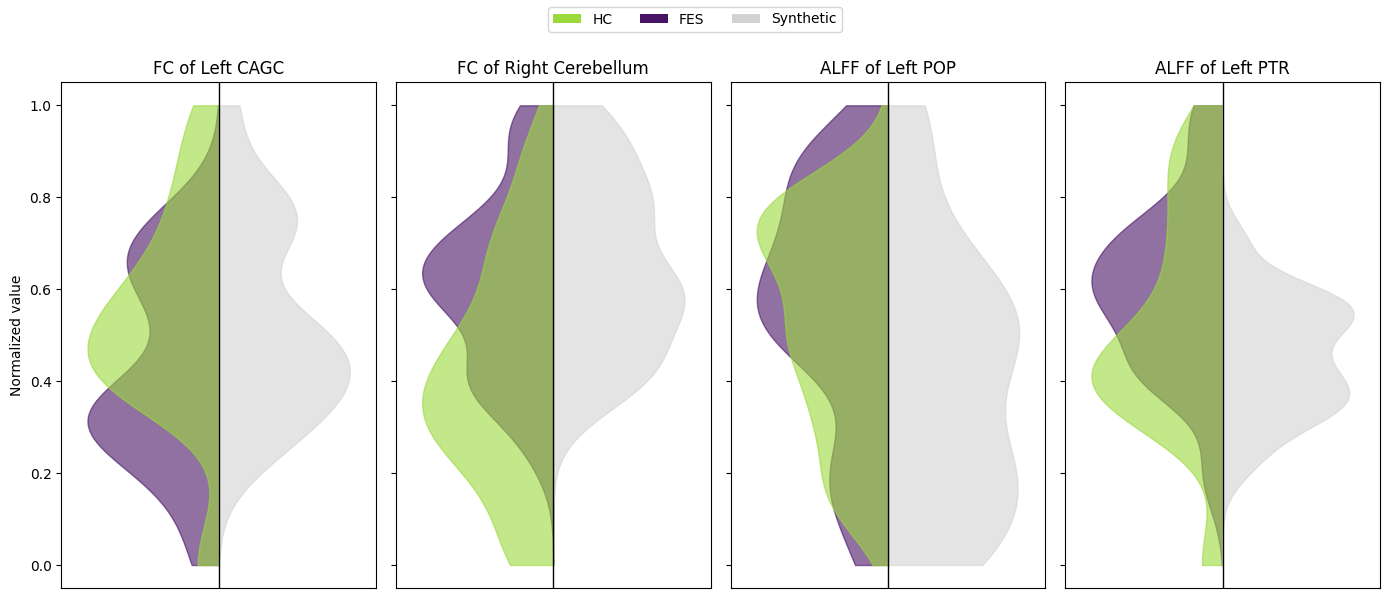

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MinMaxScaler
from matplotlib.patches import Patch

import matplotlib.cm as cm

viridis = cm.get_cmap('viridis')

hc_color = viridis(0.85)      # purple-blue
patient_color = viridis(0.05) # yellow-green

#features = {
#    'L.CACG_FC': 'FC of Left CAGC',
#    'R.CER_FC': 'FC of Right Cerebellum', 
#    'L.POP_ALFF': 'ALFF of Left POP', 
#    'L.PTR_ALFF': 'ALFF of Left PTR'
#}
features = {
    'L.CACG_FC': 'FC of Left CAGC',
    'R.CER_FC': 'FC of Right Cerebellum', 
    'L.POP_ALFF': 'ALFF of Left POP', 
    'L.PTR_ALFF': 'ALFF of Left PTR'
}


fig, axes = plt.subplots(1, len(features), figsize=(14,6), sharey=True)

for ax, (feat, label) in zip(axes, features.items()):

    # --- collect data ---
    hc = traditional.loc[traditional['diagnosis']=='HC', feat].dropna()
    patients = traditional.loc[traditional['diagnosis']!='HC', feat].dropna()
    synth = synth_res_df[feat].dropna()

    # --- normalize ---
    scaler = MinMaxScaler()
    combined = np.concatenate([hc, patients, synth]).reshape(-1,1)
    scaler.fit(combined)

    hc = scaler.transform(hc.values.reshape(-1,1)).flatten()
    patients = scaler.transform(patients.values.reshape(-1,1)).flatten()
    synth = scaler.transform(synth.values.reshape(-1,1)).flatten()

    # grid
    y = np.linspace(0,1,300)

    kde_hc = gaussian_kde(hc,bw_method=0.4)(y)
    kde_pat = gaussian_kde(patients, bw_method=0.4)(y)
    kde_syn = gaussian_kde(synth, bw_method=0.4)(y)

    kde_hc /= kde_hc.max()
    kde_pat /= kde_pat.max()
    kde_syn /= kde_syn.max()

    # left half overlays (traditional)
    ax.fill_betweenx(y, -kde_pat, 0, color=patient_color, alpha=0.6)
    ax.fill_betweenx(y, -kde_hc, 0, color=hc_color, alpha=0.6)

    # right half (synthetic)
    ax.fill_betweenx(y, 0, kde_syn, color='lightgray', alpha=0.6)

    ax.axvline(0, color='black', lw=1)

    ax.set_xlim(-1.2,1.2)
    ax.set_title(label)
    ax.set_xticks([])

axes[0].set_ylabel("Normalized value")

# legend
legend_elements = [
    Patch(facecolor=hc_color, label='HC'),
    Patch(facecolor=patient_color, label='FES'),
    Patch(facecolor='lightgray', label='Synthetic')
]

fig.legend(handles=legend_elements, loc='upper center', ncol=3)

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

In [41]:
from sklearn.linear_model import LinearRegression

X = synth_res_df.values   # n_subjects x n_synth_features
Y = trad.values           # n_subjects x n_trad_features

model = LinearRegression().fit(X, Y)
coefs = pd.DataFrame(model.coef_, columns=synth_res_df.columns, index=trad.columns)

ValueError: could not convert string to float: 'FES'